In [251]:
# Acquire normalization information
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from scipy.optimize import curve_fit
import pandas as pd
import matplotlib.patches as patches
import matplotlib.colors as colors

savedir = '/home/kale-chen/Documents/PET/Sensitivity Normalization/writeup/plots'
roundto = 8
# Geometric factors
mapdf = pd.read_csv('/home/kale-chen/Documents/PET/TPPT_Scanner_map_adjusted.csv', header = None)
map = mapdf.to_numpy()[:, 0:3]
# Axial groups
axialgroupsL = {} # (x, y) position: list of channel IDs
axialgroupsR = {}
for n in range(3072):
    if (np.round(map[n, 0], roundto), np.round(map[n, 1], roundto)) not in axialgroupsR:
        axialgroupsR[(np.round(map[n, 0], roundto), np.round(map[n, 1], roundto))] = []
    axialgroupsR[(np.round(map[n, 0], roundto), np.round(map[n, 1], roundto))].append(n)
for n in range(3072, 6144):
    if (np.round(map[n, 0], roundto), np.round(map[n, 1], roundto)) not in axialgroupsL:
        axialgroupsL[(np.round(map[n, 0], roundto), np.round(map[n, 1], roundto))] = []
    axialgroupsL[(np.round(map[n, 0], roundto), np.round(map[n, 1], roundto))].append(n)
agIDlookupL = np.zeros(3072, dtype = np.int16)
agIDlookupR = np.zeros(3072, dtype = np.int16)
for entry in range(len(axialgroupsL)):
    for id in axialgroupsL[list(axialgroupsL.keys())[entry]]:
        agIDlookupL[id - 3072] = entry
for entry in range(len(axialgroupsR)):
    for id in axialgroupsR[list(axialgroupsR.keys())[entry]]:
        agIDlookupR[id] = entry
print(axialgroupsR)
print(agIDlookupR[0:20])
# Transaxial groups
transaxialgroupsL = {}
transaxialgroupsR = {}
for n in range(3072):
    if np.round(map[n, 2], roundto) not in transaxialgroupsR:
        transaxialgroupsR[np.round(map[n, 2], roundto)] = []
    transaxialgroupsR[np.round(map[n, 2], roundto)].append(n)
for n in range(3072, 6144):
    if np.round(map[n, 2], roundto) not in transaxialgroupsL:
        transaxialgroupsL[np.round(map[n, 2], roundto)] = []
    transaxialgroupsL[np.round(map[n, 2], roundto)].append(n)
tgIDlookupL = np.zeros(3072, dtype = np.int16)
tgIDlookupR = np.zeros(3072, dtype = np.int16)
for entry in range(len(transaxialgroupsL)):
    for id in transaxialgroupsL[list(transaxialgroupsL.keys())[entry]]:
        tgIDlookupL[id - 3072] = entry
for entry in range(len(transaxialgroupsR)):
    for id in transaxialgroupsR[list(transaxialgroupsR.keys())[entry]]:
        tgIDlookupR[id] = entry
print(transaxialgroupsR)
print(tgIDlookupR[0:20])
print(len(axialgroupsL), len(axialgroupsR), len(transaxialgroupsL), len(transaxialgroupsR))
print(len(tgIDlookupL), len(tgIDlookupR), len(np.unique(agIDlookupL)), len(np.unique(tgIDlookupR)))
# Heatmap utils
heatmapmin, heatmapmax = 0.8, 1.2
def setheatmapminmax(min, max):
    global heatmapmin, heatmapmax
    heatmapmin, heatmapmax = min, max
mapL = mapdf.iloc[3072:]
mapR = mapdf.iloc[:3072]
mapL = np.round(mapL, 2)
mapR = np.round(mapR, 2)
ycoordsL, countsL = np.unique(mapL.iloc[:, 1], return_counts=True)
zcoordsL, countsL = np.unique(mapL.iloc[:, 2], return_counts=True)
ycoordsR, countsR = np.unique(mapR.iloc[:, 1], return_counts=True)
ycoordsR = ycoordsR[::-1] # To keep view from isocenter outwards
zcoordsR, countsR = np.unique(mapR.iloc[:, 2], return_counts=True)
scanner_arc_L = np.zeros((32, 96))
scanner_arc_R = np.zeros((32, 96))
for i in range(3072):
    scanner_arc_R[np.where(zcoordsR == mapR.iloc[i, 2]), np.where(ycoordsR == mapR.iloc[i, 1])] = i
for i in range(3072):
    scanner_arc_L[np.where(zcoordsL == mapL.iloc[i, 2]), np.where(ycoordsL == mapL.iloc[i, 1])] = i+3072
def getcolor(value, cmap = 'RdBu_r', numdiscretecolors = 20):
        colormap = plt.get_cmap(cmap)
        if value < heatmapmin:
            return colormap(0.0)
        elif value > heatmapmax:
            return colormap(1.0)
        else:
            return colormap((value - heatmapmin) / (heatmapmax - heatmapmin) * (numdiscretecolors - 2) // 1 / (numdiscretecolors - 2))
def makeheatmap(countsIDorder,title, name, heatmapmin = 0.80, heatmapmax = 1.20):
    setheatmapminmax(heatmapmin, heatmapmax)
    heatmapL = np.zeros((32, 96))
    heatmapR = np.zeros((32, 96))
    for i in range(3072):
        index = np.where(scanner_arc_R == i)
        heatmapR[index] = countsIDorder[i]
    for i in range(3072, 6144):
        index = np.where(scanner_arc_L == i)
        heatmapL[index] = countsIDorder[i]
    heatmapR = heatmapR / np.median(heatmapR)
    heatmapL = heatmapL / np.median(heatmapL)
    #Dead cells
    for i in range(32):
        for j in range(96):
            if heatmapR[i, j] == 0:
                heatmapR[i, j] = -1
            if heatmapL[i, j] == 0:
                heatmapL[i, j] = -1

    face_dim = 3.2
    space = 1.2
    blank_color = 'black'
    cmap = plt.get_cmap('RdBu_r') # 'seismic' or 'RdBu' or 'rwb'
        
    fig, ax = plt.subplots(figsize = (8, 6))

    #rect = patches.Rectangle((-2, -104.8), 324.4, 225.6, facecolor='black', alpha = 0.2)
    #ax.add_patch(rect)

    # Plot R
    for z in range(32):
        zspace = z // 8 * space
        for y in range(96):
            yspace = y // 8 * space
            if heatmapR[z, y] != -1:
                rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace)), face_dim, face_dim, facecolor=getcolor(heatmapR[z, y], cmap = cmap))
                ax = plt.gca()
                ax.add_patch(rect)
            else:
                rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace)), face_dim, face_dim, facecolor=blank_color)
                ax = plt.gca()
                ax.add_patch(rect)

    # Plot L
    for z in range(32):
        zspace = z // 8 * space 
        for y in range(96):
            yspace = y // 8 * space
            if heatmapL[z, y] != -1:
                rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace)+ 110), face_dim, face_dim, facecolor=getcolor(heatmapL[z, y], cmap = cmap))
                ax = plt.gca()
                ax.add_patch(rect)
            else:
                rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace) + 110), face_dim, face_dim, facecolor=blank_color)
                ax = plt.gca()
                ax.add_patch(rect)
    bounds = np.linspace(heatmapmin, heatmapmax, 21)
    norm = colors.BoundaryNorm(bounds, cmap.N)
    mappable = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = plt.colorbar(mappable, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
    diff = heatmapmax - heatmapmin
    cbar.set_ticks([heatmapmin, heatmapmin+diff*0.0, heatmapmin+diff*0.1, heatmapmin+diff*0.15, heatmapmin+diff*0.2, heatmapmin+diff*0.25, heatmapmin+diff*0.3, heatmapmin+diff*0.35, heatmapmin+diff*0.4, heatmapmin+diff*0.45, heatmapmin+diff*0.5, heatmapmin+diff*0.55, heatmapmin+diff*0.6, heatmapmin+diff*0.65, heatmapmin+diff*0.7, heatmapmin+diff*0.75, heatmapmin+diff*0.8, heatmapmin+diff*0.85, heatmapmin+diff*0.9, heatmapmin+diff*0.95, heatmapmax])
    cbar.set_ticklabels([
        '',
        #f'{heatmapmin:.2e}',
        f'{heatmapmin}',
        '', '', '', '', '', '', '', '',
        f'{heatmapmin+diff*0.5}',
        '', '', '', '', '', '', '', '', '',
        f'{heatmapmax}'
    ])
    plt.xlim(-2,322.4)
    pady = 36
    plt.ylim(-104.8 - pady, 113.2)
    plt.axis('off')
    #plt.tight_layout()
    plt.title(title)
    plt.savefig(os.path.join('plots', f'{name}heatmap.pdf'), format='pdf', dpi=300, bbox_inches='tight')
    plt.show()

def makehist(eventcounts, eventcountsIDorder, title, fit = True):
    plt.figure(1, figsize = (6, 3))
    bins = np.linspace(0.8, 1.2, 200)
    plt.hist(eventcounts / np.median(eventcounts), bins = bins, color = 'red', label = 'Unnormalized', histtype = 'step', linewidth = 1)
    hist, bins = plt.hist(eventcountsIDorder / np.median(eventcountsIDorder), bins = bins, color = 'blue', label = 'Normalized', histtype = 'step', linewidth = 1)[0:2]
    def gaussian(x, a, mu, sigma):
        return a * np.exp(-(x - mu)**2 / (2 * sigma**2))
    if fit:
        bincenters = (bins[1:] + bins[:-1]) / 2
        popt, _ = curve_fit(gaussian, bincenters, hist, p0 = [100, 1.0, 0.03])
        print(popt)
        plotting_bounds = np.linspace(popt[1] - 4 * popt[2], popt[1] + 4 * popt[2], 100)
        plt.plot(plotting_bounds, gaussian(plotting_bounds, *popt), color = 'black', label = f'sigma = {np.abs(popt[2]):.4f}')
    plt.legend()
    plt.xlim(0.78,1.22)
    plt.xlabel('Channel activity (sum across LORs) scaled to median')
    plt.ylabel('Number of channels')
    plt.title(title)
    plt.show()

xedges = np.linspace(-180, 180, 361)
yedges = np.linspace(-180, 180, 361)
def siddon(x1, y1, x2, y2, x_edges, y_edges, count):
    dx = x2 - x1
    dy = y2 - y1
    total_length = np.hypot(dx, dy)
    alphas = [0.0, 1.0]
    if dx != 0:
        ax = (x_edges - x1) / dx
        alphas.extend(ax[(ax > 0) & (ax < 1)])
    if dy != 0:
        ay = (y_edges - y1) / dy
        alphas.extend(ay[(ay > 0) & (ay < 1)])
    alphas = np.unique(np.sort(alphas))
    contribution = np.zeros((len(x_edges) - 1, len(y_edges) - 1))
    for a0, a1 in zip(alphas[:-1], alphas[1:]):
        amid = (a0 + a1) / 2
        xmid = x1 + amid * dx
        ymid = y1 + amid * dy
        ix = np.searchsorted(x_edges, xmid) - 1
        iy = np.searchsorted(y_edges, ymid) - 1
        if (0 <= ix < len(x_edges) - 1 and 0 <= iy < len(y_edges) - 1):
            length = (a1 - a0) * total_length
            contribution[iy, ix] += length * count
    return contribution
def plot_img(img, fignum, name, title, roi = 360, vmin = 0.80, vmax = 1.20, save = False):
    plt.figure(fignum, figsize = (5, 5))
    norm_img = img #/ sensimg
    norm_img = np.flip(norm_img, axis = 0)
    if roi != 360:
        norm_img = norm_img[180 - roi // 2:180 + roi // 2, 180 - roi // 2:180 + roi // 2]
    norm_img = norm_img / np.mean(norm_img)
    max_pixel = np.unravel_index(np.argmax(norm_img), norm_img.shape)
    max_pos = (-180 + max_pixel[1], 180 - max_pixel[0])
    plt.imshow(norm_img, cmap = 'hot', aspect = 'auto', vmin = vmin, vmax = vmax, extent = [-roi/2, roi/2, -roi/2, roi/2])
    #plt.plot(max_pos[0], max_pos[1], 'ro', color = 'blue', markersize = 4, alpha = 0.5)
    if roi == 180:
        plt.xticks(np.linspace(-150, 150, 11))
        plt.yticks(np.linspace(-150, 150, 11))
    else:
        plt.xticks(np.arange(-(roi / 2) // 10*10, (roi / 2) // 10*10 + 0.0001, 10))
        plt.yticks(np.arange(-(roi / 2) // 10*10, (roi / 2) // 10*10 + 0.0001, 10))
        plt.xlim(-(roi / 2), (roi / 2))
        plt.ylim(-(roi / 2), (roi / 2))
    plt.xlabel('x (mm)')
    plt.ylabel('y (mm)')
    plt.title(title)
    if save:
        pass
        #plt.savefig(os.path.join(save_dir, f'{name}.png'))
    return max_pos
mapdf = pd.read_csv('/home/kale-chen/Documents/PET/TPPT_Scanner_map_adjusted.csv', usecols=[0,1,2,3,4,5], header=None)
map = mapdf.to_numpy()[:, 0:3]
topring = map[map[:, 2] == np.max(map[:, 2])]
topringL = topring[topring[:, 0] < 0]
topringR = topring[topring[:, 0] > 0]
#print(len(topringL), len(topringR), topring[0])
yL_to_idx = {y: idx for idx, y in enumerate(topringL[:, 1])}
yR_to_idx = {y: idx for idx, y in enumerate(topringR[:, 1])}

def lor_sensitivity(xL, yL, xR, yR):
    return 1 / ((xL - xR)**2 + (yL - yR)**2)
def lor_sensitivity(idL, idR):
    return 1 / ((map[idL + 3072][0] - map[idR][0])**2 + (map[idL + 3072][1] - map[idR][1])**2)
lor_sensitivities = np.zeros((3072, 3072), dtype = np.float32)
#for i in tqdm(range(3072)):
#    for j in range(3072):
#        lor_sensitivities[i, j] = np.sqrt(lor_sensitivity(i, j))


{(np.float64(117.3250734), np.float64(-120.1245968)): [0, 3, 7, 14, 16, 18, 20, 21, 108, 110, 112, 113, 119, 120, 124, 127, 896, 899, 903, 910, 912, 914, 916, 917, 1004, 1006, 1008, 1009, 1015, 1016, 1020, 1023], (np.float64(114.8917743), np.float64(-122.2028306)): [1, 8, 10, 15, 17, 19, 22, 23, 104, 106, 109, 111, 115, 116, 117, 118, 897, 904, 906, 911, 913, 915, 918, 919, 1000, 1002, 1005, 1007, 1011, 1012, 1013, 1014], (np.float64(112.4584752), np.float64(-124.2810643)): [2, 5, 12, 13, 24, 25, 26, 28, 101, 103, 105, 107, 114, 121, 123, 125, 898, 901, 908, 909, 920, 921, 922, 924, 997, 999, 1001, 1003, 1010, 1017, 1019, 1021], (np.float64(110.0251761), np.float64(-126.3592981)): [4, 6, 9, 11, 29, 30, 31, 32, 73, 75, 97, 98, 99, 100, 122, 126, 900, 902, 905, 907, 925, 926, 927, 928, 969, 971, 993, 994, 995, 996, 1018, 1022], (np.float64(107.5918771), np.float64(-128.4375319)): [27, 33, 34, 35, 36, 38, 58, 62, 66, 68, 91, 93, 94, 95, 96, 102, 923, 929, 930, 931, 932, 934, 954, 958, 962

In [157]:
# Determine reflection equivalent groups
allaxialpairs = {}
for i in range(len(axialgroupsL)):
    yL = round(list(axialgroupsL.keys())[i][1], 4)
    for j in range(len(axialgroupsR)):
        yR = round(list(axialgroupsR.keys())[j][1], 4)
        if ((yL, yR) not in allaxialpairs and
            (yR, yL) not in allaxialpairs and
            (-yL, -yR) not in allaxialpairs and
            (-yR, -yL) not in allaxialpairs):
            allaxialpairs[(yL, yR)] = [(i, j)]
        elif (yL, yR) in allaxialpairs:
            allaxialpairs[(yL, yR)].append((i, j))
        elif (yR, yL) in allaxialpairs:
            allaxialpairs[(yR, yL)].append((i, j))
        elif (-yL, -yR) in allaxialpairs:
            allaxialpairs[(-yL, -yR)].append((i, j))
        elif (-yR, -yL) in allaxialpairs:
            allaxialpairs[(-yR, -yL)].append((i, j))
alltransaxialpairs = {}
for i in range(len(transaxialgroupsL)):
    zL = round(list(transaxialgroupsL.keys())[i], 4)
    for j in range(len(transaxialgroupsR)):
        zR = round(list(transaxialgroupsR.keys())[j], 4)
        if ((zL, zR) not in alltransaxialpairs and
            (zR, zL) not in alltransaxialpairs and
            (-zL, -zR) not in alltransaxialpairs and
            (-zR, -zL) not in alltransaxialpairs):
            alltransaxialpairs[(zL, zR)] = [(i, j)]
        elif (zL, zR) in alltransaxialpairs:
            alltransaxialpairs[(zL, zR)].append((i, j))
        elif (zR, zL) in alltransaxialpairs:
            alltransaxialpairs[(zR, zL)].append((i, j))
        elif (-zL, -zR) in alltransaxialpairs:
            alltransaxialpairs[(-zL, -zR)].append((i, j))
        elif (-zR, -zL) in alltransaxialpairs:
            alltransaxialpairs[(-zR, -zL)].append((i, j))
print(len(allaxialpairs), len(alltransaxialpairs))
totalpairsinaxial = 0
totalpairsintransaxial = 0
for key in alltransaxialpairs:
    totalpairsintransaxial += len(alltransaxialpairs[key])
for key in allaxialpairs:
    totalpairsinaxial += len(allaxialpairs[key])
print(totalpairsinaxial, totalpairsintransaxial)
def symmetrizeaxialpairs(axialpairs):
    for pairs in allaxialpairs.values():
        val = 0
        for pair in pairs:
            val += axialpairs[pair[0], pair[1]]
        val /= len(pairs)
        for pair in pairs:
            axialpairs[pair[0], pair[1]] = val
def symmetrizetransaxialpairs(transaxialpairs):
    for pairs in alltransaxialpairs.values():
        val = 0
        for pair in pairs:
            val += transaxialpairs[pair[0], pair[1]]
        val /= len(pairs)
        for pair in pairs:
            transaxialpairs[pair[0], pair[1]] = val

2352 272
9216 1024


In [9]:
def solve_intersections(xL, yL, xR, yR, r = 120):
    dx, dy = xR - xL, yR - yL
    A = dx**2 + dy**2
    B = 2 * (xL * dx + yL * dy)
    C = xL**2 + yL**2 - r**2
    discriminant = B**2 - 4*A*C
    if discriminant < 0:
        # No real intersections
        return []
    elif discriminant == 0:
        t = -B / (2*A)
        intersection1 = (xL + t*dx, yL + t*dy)
        return [intersection1]
    else:
        sqrt_disc = np.sqrt(discriminant)
        t1 = (-B + sqrt_disc) / (2*A)
        t2 = (-B - sqrt_disc) / (2*A)
        intersection1 = (xL + t1*dx, yL + t1*dy)
        intersection2 = (xL + t2*dx, yL + t2*dy)
        return [intersection1, intersection2]
def solve_intersections_vertical(xL, yL, xR, yR):
    dx = xR - xL
    dy = yR - yL
    t = -xL / dx
    y_intersect = yL + t * dy
    return (0, y_intersect)
    
def distance(xL, yL, xR, yR):
    return np.sqrt((xL - xR)**2 + (yL - yR)**2)
def quickplot(x, y, color):
    print(round(x, 3), round(y, 3))
    plt.scatter(x, y, color = color)



In [254]:
# Component-based normalization
name = 'hcircpgd'
path = f'/home/kale-chen/Documents/PET/TPPT2026/data/hcircpgd.bin'
#path = '/home/kale-chen/Documents/Geant4/TPPTsim/temp/idsmapped.bin'
num_cols, data_size = 4,2
num_rows = os.path.getsize(path) // (num_cols * data_size)
data1 = np.memmap(path, dtype = np.int16, mode = 'r', shape = (num_rows, num_cols))
eventcounts = np.zeros((3072, 3072), dtype = np.float32)
#axialpairs = np.zeros((96, 96), dtype = np.float32)
axialpairs = np.zeros((len(axialgroupsL), len(axialgroupsL)), dtype = np.float32)
transaxialpairs = np.zeros((len(transaxialgroupsL), len(transaxialgroupsL)), dtype = np.float32)
normfactorsL = np.fromfile('normfactors/it4L.bin', dtype = np.float32)
normfactorsR = np.fromfile('normfactors/it4R.bin', dtype = np.float32)
for i in tqdm(range(0, num_rows, 1000000), desc='Event counts'):
    chunk = data1[i:i+1000000]
    if num_cols == 3 or num_cols == 2 or num_cols == 4:
        idls = np.asarray(chunk[:, 0], dtype = np.int32)
        idrs = np.asarray(chunk[:, 1], dtype = np.int32)
    elif num_cols == 6:
        idls = np.asarray(chunk[:, 1], dtype = np.int32)
        idrs = np.asarray(chunk[:, 3], dtype = np.int32)
    np.add.at(axialpairs, (agIDlookupL[idls], agIDlookupL[idrs]), 1)
    #np.add.at(axialpairs, (agIDlookupL[idls], agIDlookupL[idrs]), 1 / (normfactorsL[idls] * normfactorsR[idrs]))
    np.add.at(transaxialpairs, (tgIDlookupL[idls], tgIDlookupL[idrs]), 1)
    #np.add.at(transaxialpairs, (tgIDlookupL[idls], tgIDlookupL[idrs]), 1 / (normfactorsL[idls] * normfactorsR[idrs]))
    #np.add.at(eventcounts, (idls, idrs), lor_sensitivities[idls, idrs])
    np.add.at(eventcounts, (idls, idrs), 1)
    #np.add.at(eventcounts, (idls, idrs), 1 / (normfactorsL[idls] * normfactorsR[idrs]))
print(np.sum(eventcounts))
eventcountsIDorder = np.concatenate((eventcounts.sum(axis = 0), eventcounts.sum(axis = 1)), axis = 0)
efficiencies = eventcountsIDorder
efficiencies[efficiencies == 0] = 1
efficiencies = 1 / efficiencies
#efficiencies = efficiencies / np.mean(efficiencies)
print(efficiencies, np.sum(efficiencies))
symmetrizeaxialpairs(axialpairs)
symmetrizetransaxialpairs(transaxialpairs)
axialpairs[axialpairs == 0] = np.mean(axialpairs)
gaxial = 1 / axialpairs
gtrans = 1 / transaxialpairs
print(gaxial[0][0:3], gaxial.shape, np.sum(gaxial))
print(gtrans[0][0:3], gtrans.shape, np.sum(gtrans))

Event counts: 100%|██████████| 20/20 [00:03<00:00,  6.61it/s]

1.9704008e+07
[0.00013714 0.00013732 0.0001296  ... 0.00013493 0.0001291  0.00010595] 8.011471
[0.00057963 0.00057102 0.00056196] (96, 96) 5.4075108
[5.2159397e-05 5.1524479e-05 5.1712323e-05] (32, 32) 0.053278435


In [180]:
#axialpairs1 = axialpairs.copy()
#transaxialpairs1 = transaxialpairs.copy()
axialpairs2 = axialpairs.copy()
transaxialpairs2 = transaxialpairs.copy()


100
64 64
64.0


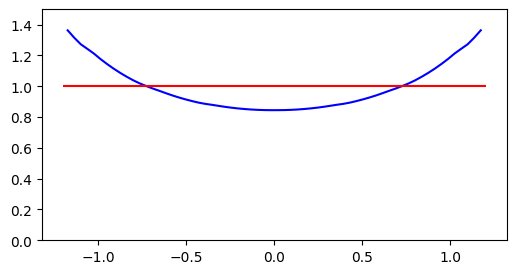

In [37]:
angularpoints = np.column_stack((bin_centers, mean_rdists))
print(len(angularpoints))
mask = (angularpoints[:,0] < 1.2) & (angularpoints[:,0] > -1.2)
angularpoints = angularpoints[mask]
print(len(angularpoints[:, 0]), len(angularpoints[:, 1]))
#angularpoints[:, 1] = angularpoints[:, 1] / np.mean(angularpoints[:, 1])
angularpoints[:, 1] = 1/angularpoints[:,1]**2
angularpoints[:, 1] = angularpoints[:, 1] / np.mean(angularpoints[:, 1])
print(np.sum(angularpoints[:, 1]))
plt.figure(1, figsize = (6, 3))
plt.plot(angularpoints[:,0], angularpoints[:,1], color = 'blue', label = 'a/(maxsourcedist)^2')
plt.hlines(1, -1.2, 1.2, color = 'red', label = '1')
plt.ylim(0, 1.5)
def getxysensitivity(angle):
    if angle < -1.2 or angle > 1.2:
        return 0
    x = angularpoints[:, 0]
    y = angularpoints[:, 1]
    return np.interp(angle, x, y)
def getzsensitivity(zdiff):
    return 1 # For now, we assume the z-sensitivity is constant

In [ ]:
# Construct the sensitivity matrix
geomsensitivity = np.zeros((3072, 3072), dtype = np.float32)
acceptancetable = np.zeros((3072, 3072), dtype = np.bool)
for i in tqdm(range(3072)):
    xL, yL = map[i + 3072][0], map[i + 3072][1]
    angleL = np.arctan2(yL, xL)
    angleL = angleL + 2 * np.pi if angleL < 0 else angleL
    angleL -= np.pi
    for j in range(3072):
        xR, yR = map[j][0], map[j][1]
        angleR = np.arctan2(yR, xR)
        angle = angleL - angleR
        zdiff = 0
        sensitivity = getxysensitivity(angle) * getzsensitivity(zdiff)
        geomsensitivity[i, j] = sensitivity
        acceptancetable[i, j] = True if sensitivity > 0 else False
print(np.sum(acceptancetable))
geomsensitivity.tofile('geomsensitivity.bin')
acceptancetable.tofile('acceptancetable.bin')



100%|██████████| 3072/3072 [00:20<00:00, 149.76it/s]


8218624


In [154]:
def lor_to_sinogram_coords(x1, y1, x2, y2):
    dx = x2 - x1
    dy = y2 - y1
    nx = -dy
    ny = dx
    norm = np.hypot(nx, ny)
    nx /= norm
    ny /= norm
    s = x1 * nx + y1 * ny
    return s
acceptancetable = np.ones((3072, 3072), dtype = np.bool)
for i in tqdm(range(3072)):
    for j in range(3072):
        x1, y1 = map[i + 3072][0], map[i + 3072][1]
        x2, y2 = map[j][0], map[j][1]
        s = lor_to_sinogram_coords(x1, y1, x2, y2)
        if np.abs(s) > 115:
            acceptancetable[i, j] = False
acceptancetable.tofile('acceptancetable.bin')
print(np.sum(acceptancetable))

100%|██████████| 3072/3072 [00:13<00:00, 225.98it/s]

9066496


In [255]:
# Construct the sensitivity matrix method b
geomsensitivity = np.zeros((3072, 3072), dtype = np.float32)
for i in tqdm(range(3072)):
    radialIDL = agIDlookupL[i]
    axialIDL = tgIDlookupL[i]
    for j in range(3072):
        radialIDR = agIDlookupR[j]
        axialIDR = tgIDlookupR[j]
        geomsensitivity[i, j] = axialpairs[radialIDL, radialIDR] * transaxialpairs[axialIDL, axialIDR]
geomsensitivity = geomsensitivity / np.mean(geomsensitivity)
print(np.mean(geomsensitivity))
acceptancetable = np.ones((3072, 3072), dtype = np.bool)
acceptancetable.tofile('acceptancetable.bin')
geomsensitivity.tofile('geomsensitivity.bin')

  0%|          | 0/3072 [00:00<?, ?it/s]

100%|██████████| 3072/3072 [00:03<00:00, 814.78it/s]

1.0


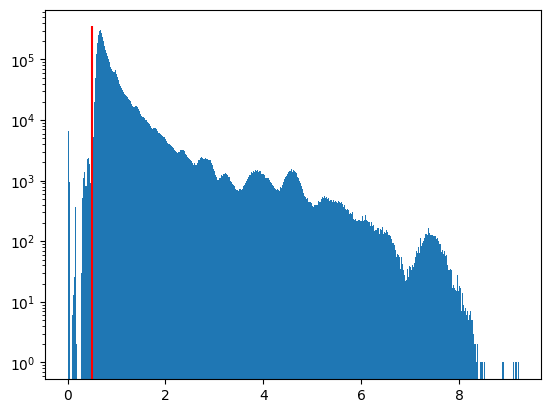

In [112]:
plt.hist(geomsensitivity.flatten()*acceptancetable.flatten(), bins = 1000)
plt.vlines(0.5, 0, 350000, color = 'red')
plt.yscale('log')
plt.show()

In [ ]:
# Construct an estimate for g_detector
gdetector = np.zeros((3072, 3072), dtype = np.float32)
for i in tqdm(range(3072)):
    for j in range(3072):
        gdetector[i, j] = 
gdetector = gdetector / np.mean(gdetector)
gdetector.tofile('gdetector.bin')


233


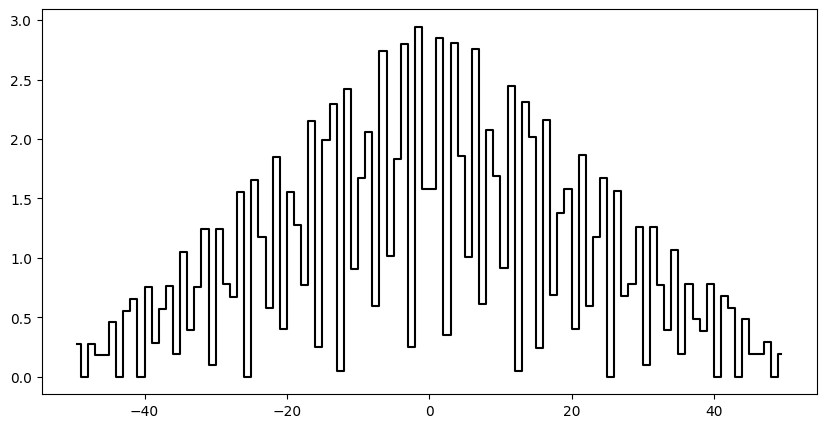

In [125]:
uniquez = np.unique(map[:, 2])
zmidpoints = []
for zL in uniquez:
    for zR in uniquez:
        zmidpoints.append((zL + zR) / 2)
zmidpoints = np.array(zmidpoints)
print(len(np.unique(zmidpoints)))
hist, bins = np.histogram(zmidpoints, bins = np.linspace(-50.5, 50.5, 102))
bincenters = bins[:-1] + np.diff(bins) / 2
hist = hist / np.mean(hist)
plt.figure(1, figsize = (10, 5))
#plt.step(bincenters, hist, color = 'red', where = 'mid')


sensitivitymap = np.fromfile('/home/kale-chen/Documents/CASToR/images/hcenterfinal1n/hcenterfinal1n_sensitivity.img', dtype = np.float32).reshape((20, 20, 100), order = 'F')
sensitivitymap = sensitivitymap[9:11, 9:11, :]
zproj = np.sum(sensitivitymap, axis = (0, 1))
zproj = zproj / np.mean(zproj)
plt.step(np.linspace(-49.5, 49.5, 100), zproj, color = 'black', where = 'mid')
plt.show()

  0%|          | 0/3072 [00:00<?, ?it/s]

100%|██████████| 3072/3072 [00:07<00:00, 413.63it/s]


array([<Axes: >, <Axes: >], dtype=object)

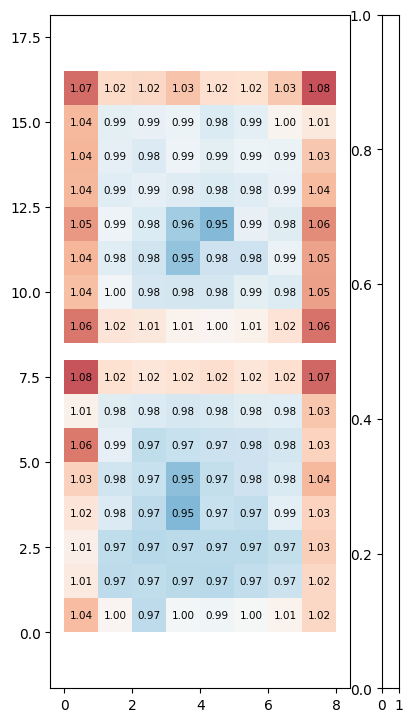

In [ ]:
indices = {
      0 : (4,7-7),
      1 : (4,7-6),
      2 : (7,7-5),
      3 : (5,7-7),
      4 : (5,7-4),
      5 : (5,7-5),
      6 : (4,7-4),
      7 : (7,7-7),
      8 : (6,7-6),
      9 : (7,7-4),
      10 : (5,7-6),
      11 : (6,7-4),
      12 : (4,7-5),
      13 : (6,7-5),
      14 : (6,7-7),
      15 : (7,7-6),
      16 : (3,7-7),
      17 : (3,7-6),
      18 : (2,7-7),
      19 : (2,7-6),
      20 : (0,7-7),
      21 : (1,7-7),
      22 : (0,7-6),
      23 : (1,7-6),
      24 : (3,7-5),
      25 : (1,7-5),
      26 : (2,7-5),
      27 : (4,7-3),
      28 : (0,7-5),
      29 : (3,7-4),
      30 : (0,7-4),
      31 : (1,7-4),
      32 : (2,7-4),
      33 : (3,7-3),
      34 : (2,7-3),
      35 : (0,7-3),
      36 : (1,7-3),
      37 : (0,7-2),
      38 : (5,7-3),
      39 : (1,7-2),
      40 : (2,7-2),
      41 : (3,7-2),
      42 : (1,7-1),
      43 : (0,7-1),
      44 : (0,7-0),
      45 : (3,7-1),
      46 : (1,7-0),
      47 : (2,7-1),
      48 : (3,7-0),
      49 : (2,7-0),
      50 : (6,7-2),
      51 : (6,7-1),
      52 : (7,7-1),
      53 : (4,7-1),
      54 : (5,7-1),
      55 : (6,7-0),
      56 : (7,7-0),
      57 : (7,7-2),
      58 : (7,7-3),
      59 : (4,7-2),
      60 : (5,7-0),
      61 : (5,7-2),
      62 : (6,7-3),
      63 : (4,7-0),
      64:(3+8,7),
      65:(3+8,6),
      66:(2+8,4),
      67:(2+8,6),
      68:(3+8,4),
      69:(1+8,7),
      70:(1+8,5),
      71:(0+8,7),
      72:(1+8,6),
      73:(3+8,3),
      74:(2+8,7),
      75:(2+8,3),
      76:(3+8,5),
      77:(0+8,5),
      78:(2+8,5),
      79:(0+8,6),
      80:(4+8,7),
      81:(6+8,7),
      82:(5+8,7),
      83:(7+8,7),
      84:(5+8,6),
      85:(4+8,6),
      86:(6+8,6),
      87:(7+8,6),
      88:(4+8,5),
      89:(6+8,5),
      90:(5+8,5),
      91:(1+8,4),
      92:(7+8,5),
      93:(7+8,4),
      94:(6+8,4),
      95:(4+8,4),
      96:(5+8,4),
      97:(5+8,3),
      98:(6+8,3),
      99:(4+8,3),
      100:(7+8,3),
      101:(7+8,2),
      102:(0+8,4),
      103:(6+8,2),
      104:(7+8,1),
      105:(5+8,2),
      106:(6+8,1),
      107:(4+8,2),
      108:(7+8,0),
      109:(5+8,1),
      110:(6+8,0),
      111:(4+8,1),
      112:(5+8,0),
      113:(4+8,0),
      114:(0+8,2),
      115:(2+8,1),
      116:(0+8,1),
      117:(3+8,1),
      118:(1+8,1),
      119:(1+8,0),
      120:(0+8,0),
      121:(1+8,2),
      122:(1+8,3),
      123:(3+8,2),
      124:(2+8,0),
      125:(2+8,2),
      126:(0+8,3),
      127:(3+8,0)}

modulecounts = np.zeros(128)
for i in tqdm(range(3072)):
    for j in range(3072):
        modulecounts[i % 128] += eventcounts[i, j]
        modulecounts[j % 128] += eventcounts[i, j]

modulecounts = modulecounts / np.mean(modulecounts)

scalebounds = (0.9, 1.1)
def getColor(modulecount):
    scaled = (modulecount - scalebounds[0]) / (scalebounds[1] - scalebounds[0])
    return plt.cm.RdBu_r(scaled)

fig, subplots = plt.subplots(1, 2, figsize=(4.5, 8.75), gridspec_kw={'width_ratios': [8.5, 0.5]})
bounds = (-5, 5)
for n in range(0, 128):
    y, x = indices[n]
    y = 15 - y
    if y > 7.5:
        y += 0.5
    rect = patches.Rectangle((x, y), 1, 1, linewidth=0, facecolor=getColor(modulecounts[n]), alpha=0.8)
    subplots[0].add_patch(rect)
    subplots[0].text(x + 0.5, y + 0.5, f'{modulecounts[n]:.3f}', fontsize=7.5, ha='center', va='center')

subplots[0].set_xlim(-0.25, 8.25)
subplots[0].set_ylim(-9, 8.5)
subplots[0].axis('equal')
subplots.set_spines

145.82766990291262


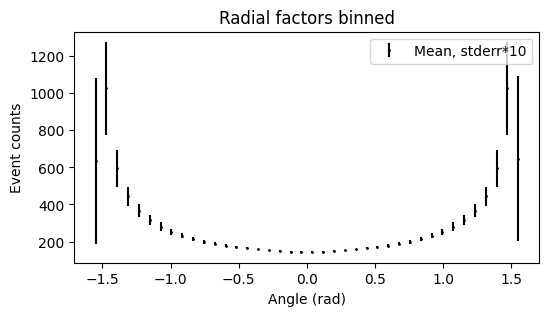

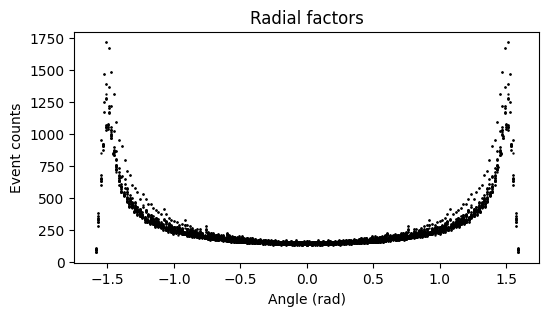

In [167]:
angles = []
counts = []
rdists = []
posL = list(axialgroupsL.keys())
posR = list(axialgroupsR.keys())
for i in range(96):
    xL, yL = posL[i]
    angleL = np.arctan2(yL, xL)
    angleL = angleL + 2 * np.pi if angleL < 0 else angleL
    angleL -= np.pi
    for j in range(96):
        xR, yR = posR[j]
        try:
            in1, in2 = solve_intersections(xL, yL, xR, yR)
            restrictivedistance = max(distance(xL, yL, in1[0], in1[1]), distance(xL, yL, in2[0], in2[1]))
            #in1 = solve_intersections_vertical(xL, yL, xR, yR)
            #restrictivedistance = max(distance(xL, yL, in1[0], in1[1]), distance(xR, yR, in1[0], in1[1]))
            rdists.append(restrictivedistance)
            angleR = np.arctan2(yR, xR)
            angle = angleL - angleR
            angles.append(angle)
            #angles.append(angleR)
            counts.append(axialpairs[i, j])
        except:
            pass
rdists = rdists / np.max(rdists)
geomdata = np.array([angles, counts, rdists])
num_bins, exaggeratestd = 40, 10
bins = np.linspace(np.min(geomdata[0]), np.max(geomdata[0]), num_bins + 1)
bin_indices = np.digitize(geomdata[0], bins) - 1  # bin_indices takes values 0 to num_bins-1

mean_counts = []
std_counts = []
mean_rdists = []
bin_centers = []
for b in range(num_bins):
    mask = bin_indices == b
    if np.any(mask):
        mean_counts.append(np.mean(geomdata[1][mask]))
        std_counts.append(np.std(geomdata[1][mask]) / np.sqrt(np.sum(mask)) * exaggeratestd)
        bin_centers.append(0.5*(bins[b] + bins[b+1]))
        mean_rdists.append(np.mean(geomdata[2][mask]))
    else:
        mean_counts.append(np.nan)
        std_counts.append(np.nan)
        bin_centers.append(0.5*(bins[b] + bins[b+1]))
        mean_rdists.append(np.nan)
mean_counts = np.array(mean_counts)
std_counts = np.array(std_counts)
bin_centers = np.array(bin_centers)
mean_rdists = np.array(mean_rdists) / mean_rdists[len(bin_centers) // 2]

# Plot mean and deviation as errorbars
plt.figure(figsize = (6, 3))
plt.errorbar(bin_centers, mean_counts, yerr=std_counts, fmt='o',
label = 'Mean, stderr*10', color='black', markersize = 1)
print(mean_counts[len(bin_centers) // 2])
#plt.plot(bin_centers, mean_counts[len(bin_centers) // 2]/mean_rdists**2, color = 'blue', label = 'a/(maxsourcedist)^2')
#plt.plot(bin_centers, 7820/((1 - np.cos(np.pi - bin_centers))), color = 'red', label = 'a/r^2')
plt.legend()
plt.xlabel('Angle (rad)')
plt.ylabel('Event counts')
plt.title('Radial factors binned')
#plt.yscale('log')
#plt.ylim(3500, 12500)
#plt.ylim(3000, 9000)
#plt.savefig(os.path.join(savedir, 'radialfactorsbinned.pdf'), dpi=300, bbox_inches='tight')
plt.show()
plt.figure(1, figsize = (6, 3))
plt.scatter(geomdata[0], geomdata[1], s = 0.5, color = 'black')
#plt.plot(bin_centers, mean_counts[len(bin_centers) // 2]/mean_rdists**2, color = 'blue', label = 'a/(maxsourcedist)^2')
#plt.plot(bin_centers, 7820/((1 - np.cos(np.pi - bin_centers))), color = 'red', label = 'a/r^2')

#plt.ylim(3500, 12500)
plt.xlabel('Angle (rad)')
plt.ylabel('Event counts')
plt.title('Radial factors')
#plt.savefig(os.path.join(savedir, 'radialfactors.pdf'), dpi=300, bbox_inches='tight')
plt.show()

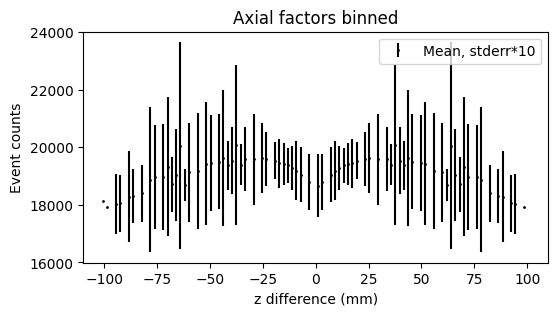

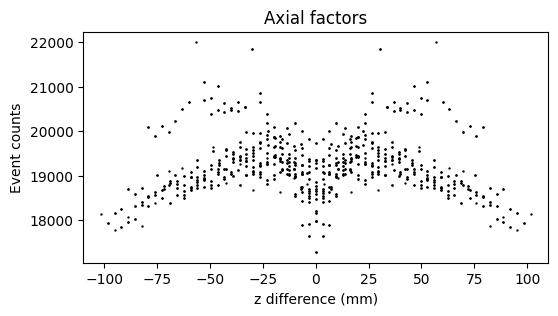

In [164]:
zdiffs = []
counts = []
posL = list(transaxialgroupsL.keys())
posR = list(transaxialgroupsR.keys())
for i in range(32):
    zL = posL[i]
    #if np.abs(zL - target) > 1.6:
    #   continue
    #print(zL)
    for j in range(32):
        zR =  posR[j]
        #zdiffs.append(np.arctan2((zL - zR), 135))
        zdiffs.append((zL - zR))
        #zdiffs.append(zL)
        counts.append(transaxialpairs[i, j])
zdiffs, counts = np.array(zdiffs), np.array(counts)
geomdata = np.array([zdiffs, counts])
num_bins, exaggeratestd = 100, 10
bins = np.linspace(np.min(geomdata[0]), np.max(geomdata[0]), num_bins + 1)
bin_indices = np.digitize(geomdata[0], bins) - 1  # bin_indices takes values 0 to num_bins-1

mean_counts = []
std_counts = []
bin_centers = []
for b in range(num_bins):
    mask = bin_indices == b
    if np.any(mask):
        mean_counts.append(np.mean(geomdata[1][mask]))
        std_counts.append(np.std(geomdata[1][mask]) / np.sqrt(np.sum(mask)) * exaggeratestd)
        bin_centers.append(0.5*(bins[b] + bins[b+1]))
    else:
        mean_counts.append(np.nan)
        std_counts.append(np.nan)
        bin_centers.append(0.5*(bins[b] + bins[b+1]))
mean_counts = np.array(mean_counts)
std_counts = np.array(std_counts)
bin_centers = np.array(bin_centers)

plt.figure(figsize = (6, 3))
plt.errorbar(bin_centers, mean_counts, yerr=std_counts, fmt='o',
label = 'Mean, stderr*10', color='black', markersize = 1)
#plt.xlabel('Angle (rad)')
plt.xlabel('z difference (mm)')
plt.ylabel('Event counts')
plt.title('Axial factors binned')
#plt.ylim(34800,60200)
plt.legend()
plt.xlim(-110, 110)
plt.savefig(os.path.join(savedir, 'axialfactorsbinned.pdf'), dpi=300, bbox_inches='tight')
plt.show()
plt.figure(1, figsize = (6, 3))
plt.scatter(geomdata[0], geomdata[1], s = 0.5, color = 'black')
#plt.xlabel('Angle (rad)')
plt.xlabel('z difference (mm)')
plt.ylabel('Event counts')
plt.title('Axial factors')
#plt.ylim(34800,60200)
plt.xlim(-110, 110)
plt.savefig(os.path.join(savedir, 'axialfactors.pdf'), dpi=300, bbox_inches='tight')
plt.show()

In [219]:
angles, counts1, counts2 = [], [], []
posL = list(axialgroupsL.keys())
posR = list(axialgroupsR.keys())
for i in range(96):
    xL, yL = posL[i]
    angleL = np.arctan2(yL, xL)
    angleL = angleL + 2 * np.pi if angleL < 0 else angleL
    angleL -= np.pi
    for j in range(96):
        xR, yR = posR[j]
        try:
            angleR = np.arctan2(yR, xR)
            angle = angleL - angleR
            angles.append(angle)
            counts1.append(axialpairs1[i, j])
            counts2.append(axialpairs2[i, j])
        except:
            pass
print(len(angles), len(counts1), len(counts2))
geomdata = np.array([angles, counts1, counts2])
num_bins = 50
bins = np.linspace(np.min(geomdata[0]), np.max(geomdata[0]), num_bins + 1)
bin_indices = np.digitize(geomdata[0], bins) - 1  # bin_indices takes values 0 to num_bins-1
mean_counts, mean_counts2, bin_centers = [], [], []
for b in range(num_bins):
    mask = bin_indices == b
    if np.any(mask):
        mean_counts.append(np.mean(geomdata[1][mask]))
        mean_counts2.append(np.mean(geomdata[2][mask]))
        bin_centers.append(0.5*(bins[b] + bins[b+1]))
mean_counts = np.array(mean_counts) / np.median(mean_counts)
mean_counts2 = np.array(mean_counts2) / np.median(mean_counts2)
bin_centers = np.array(bin_centers)

zdiffs, counts1z, counts2z = [], [], []
posL = list(transaxialgroupsL.keys())
posR = list(transaxialgroupsR.keys())
for i in range(32):
    zL = posL[i]
    for j in range(32):
        zR =  posR[j]
        zdiffs.append((zL - zR))
        counts1z.append(transaxialpairs1[i, j])
        counts2z.append(transaxialpairs2[i, j])
zdiffs, counts1z, counts2z = np.array(zdiffs), np.array(counts1z), np.array(counts2z)
geomdata = np.array([zdiffs, counts1z, counts2z])
bins = np.linspace(np.min(geomdata[0]), np.max(geomdata[0]), num_bins + 1)
bin_indices = np.digitize(geomdata[0], bins) - 1  # bin_indices takes values 0 to num_bins-1
mean_counts1z, mean_counts2z, bin_centersz = [], [], []
for b in range(num_bins):
    mask = bin_indices == b
    if np.any(mask):
        mean_counts1z.append(np.mean(geomdata[1][mask]))
        mean_counts2z.append(np.mean(geomdata[2][mask]))
        bin_centersz.append(0.5*(bins[b] + bins[b+1]))
mean_counts1z = np.array(mean_counts1z) / np.median(mean_counts1z)
mean_counts2z = np.array(mean_counts2z) / np.median(mean_counts2z)
bin_centersz = np.array(bin_centersz)



9216 9216 9216


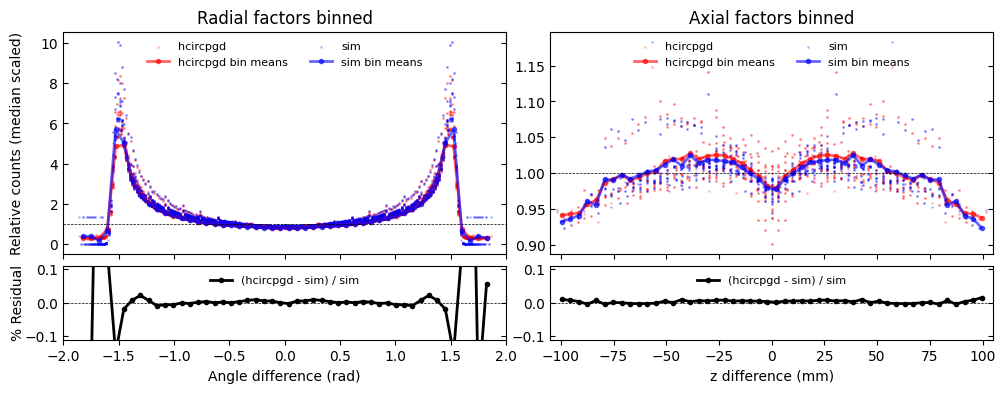

In [ ]:
# Plot mean and deviation as errorbars
fig, ax = plt.subplots(2, 2, figsize = (12, 4), gridspec_kw = {'width_ratios': [1, 1], 'height_ratios': [3, 1]})
ax = ax.flatten()
ax[0].scatter(angles, counts1 / np.median(counts1), color = 'red', marker = 'o', s = 1, alpha = 0.2, label = 'hcircpgd')
ax[0].plot(bin_centers, mean_counts, color = 'red', linewidth = 2, marker = 'o', markersize = 3, alpha = 0.6, label = 'hcircpgd bin means')
ax[0].scatter(angles, counts2 / np.median(counts2), color = 'blue', marker = 'o', s = 1, alpha = 0.2, label = 'sim')
ax[0].plot(bin_centers, mean_counts2, color = 'blue', linewidth = 2, marker = 'o', markersize = 3, alpha = 0.6, label = 'sim bin means')
ax[0].hlines(1, -2, 2, color = 'black', linestyle = '--', linewidth = 0.5)
ax[0].set_xlim(-2, 2)
ax[0].set_ylabel('Relative counts (median scaled)', labelpad = 12)
ax[0].set_title('Radial factors binned')
ax[0].set_xticklabels([])
ax[2].plot(bin_centers, (mean_counts - mean_counts2) / mean_counts2, color = 'black', marker = 'o', markersize = 3, linewidth = 2, label = '(hcircpgd - sim) / sim')
ax[2].hlines(0, -2, 2, color = 'black', linestyle = '--', linewidth = 0.5)
ax[2].set_xlim(-2, 2)
ax[2].set_ylim(-0.11, 0.11)
ax[2].set_xlabel('Angle difference (rad)')
ax[2].set_ylabel('Residual', labelpad = 0)
ax[1].scatter(zdiffs, counts1z / np.median(counts1z), color = 'red', marker = 'o', s = 1, alpha = 0.2, label = 'hcircpgd')
ax[1].plot(bin_centersz, mean_counts1z, color = 'red', linewidth = 2, marker = 'o', markersize = 3, alpha = 0.6, label = 'hcircpgd bin means')
ax[1].scatter(zdiffs, counts2z / np.median(counts2z), color = 'blue', marker = 'o', s = 1, alpha = 0.2, label = 'sim')
ax[1].plot(bin_centersz, mean_counts2z, color = 'blue', linewidth = 2, marker = 'o', markersize = 3, alpha = 0.6, label = 'sim bin means')
ax[1].hlines(1, -105, 105, color = 'black', linestyle = '--', linewidth = 0.5)
ax[1].set_title('Axial factors binned')
ax[1].set_xlim(-105, 105)
ax[1].set_xticklabels([])
ax[3].plot(bin_centersz, (mean_counts1z - mean_counts2z) / mean_counts2z, color = 'black', marker = 'o', markersize = 3, linewidth = 2, label = '(hcircpgd - sim) / sim')
ax[3].hlines(0, -105, 105, color = 'black', linestyle = '--', linewidth = 0.5)
ax[3].set_xlim(-105, 105)
ax[3].set_ylim(-0.11, 0.11)
ax[3].set_xlabel('z difference (mm)')
for axi in ax:
    axi.yaxis.set_ticks_position('both')
    axi.tick_params(axis='y', which='both', direction='in', left=True, right=True)
    axi.legend(loc = 'upper center', ncol = 2, frameon = False, fontsize = 8)
plt.subplots_adjust(wspace = 0.1, hspace = 0.08)
plt.savefig(os.path.join(savedir, 'radialaxialfactors.pdf'), dpi=300, bbox_inches='tight')
plt.show()

In [116]:
# Component-based normalization
name = 'hcircpgd'
path = f'/home/kale-chen/Documents/PET/TPPT2026/data/{name}.bin'
#path = '/home/kale-chen/Documents/Geant4/TPPTsim/temp/idsmapped.bin'
num_cols, data_size = 4,  2
num_rows = os.path.getsize(path) // (num_cols * data_size)
data1 = np.memmap(path, dtype = np.int16, mode = 'r', shape = (num_rows, num_cols))
angularhist, angularbins = np.zeros(100), np.linspace(-1, 1, 101)
for i in tqdm(range(0, num_rows, 1000000), desc='Event counts'):
    chunk = data1[i:i+1000000]
    if num_cols == 3 or num_cols == 2 or num_cols == 4:
        idls = np.asarray(chunk[:, 0], dtype = np.int32)
        idrs = np.asarray(chunk[:, 1], dtype = np.int32)
    elif num_cols == 6:
        idls = np.asarray(chunk[:, 1], dtype = np.int32)
        idrs = np.asarray(chunk[:, 3], dtype = np.int32)
    dx = map[idrs, 0] - map[idls + 3072, 0]
    dy = map[idrs, 1] - map[idls + 3072, 1]
    angles = np.arctan2(dy, dx)
    hist, _ = np.histogram(angles, bins = angularbins)
    angularhist += hist

Event counts: 100%|██████████| 20/20 [00:00<00:00, 39.03it/s]


In [117]:
angularhist1, angularbins1 = angularhist, angularbins
#angularhist2, angularbins2 = angularhist, angularbins

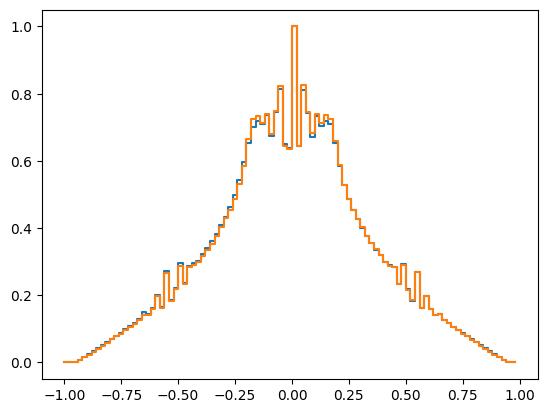

In [118]:
plt.step(angularbins1[:-1], angularhist1 / np.max(angularhist1), where = 'post')
plt.step(angularbins2[:-1], angularhist2 / np.max(angularhist2), where = 'post')
plt.show()